Minimum: 32.0
Q1: 54.0
Median: 67.0
Q3: 89.0
Maximum: 200.0
IQR: 35.0
Lower Bound: 1.5
Upper Bound: 141.5


<Axes: >

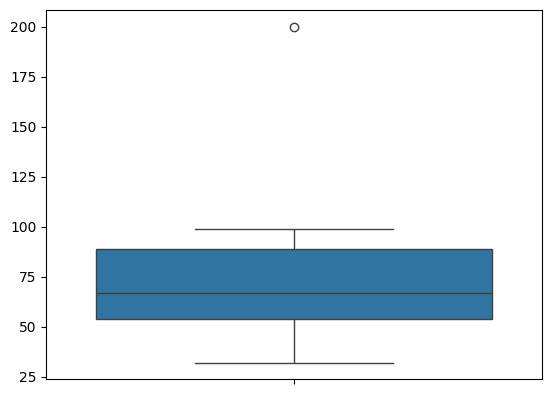

In [6]:
# Handling Outliers in Feature Engineering
import numpy as np
lst=[45,32,56,75,89,54,32,89,90,87,67,54,45,98.99,67,74,200]

minimum, q1,median, q3, maximum = np.quantile(lst, [0, 0.25, 0.50, 0.75, 1.00])
print("Minimum:", minimum)
print("Q1:", q1)
print("Median:", median)
print("Q3:", q3)
print("Maximum:", maximum)

# Calculate the IQR
iqr = q3 - q1
print("IQR:", iqr)

# Calculate the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr    

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

import seaborn as sns
sns.boxplot(lst)


In [7]:
#Upsampling and Downsampling

import pandas as pd

# Create imbalanced dataset
data = {
    "feature": list(range(20)),
    "target": [0]*18 + [1]*2   # 18 zeros, 2 ones
}

df = pd.DataFrame(data)

print(df["target"].value_counts())

target
0    18
1     2
Name: count, dtype: int64


In [ ]:
#upsampling the minority class

from sklearn.utils import resample

# Separate classes
df_majority = df[df.target == 0]
df_minority = df[df.target == 1]

# Upsample minority
df_minority_upsampled = resample(
    df_minority,
    replace=True,              # allow duplication
    n_samples=len(df_majority), # match majority size
    random_state=42
)

# Combine
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

# Check balance
print(df_upsampled["target"].value_counts())

target
0    18
1    18
Name: count, dtype: int64


In [13]:
df_minority_upsampled

,feature,target
18,18,1
19,19,1
18,18,1
18,18,1
18,18,1
19,19,1
18,18,1
18,18,1
18,18,1
19,19,1


In [14]:
# Downsample majority
df_majority_downsampled = resample(
    df_majority,
    replace=False,             # no duplication
    n_samples=len(df_minority), # match minority size
    random_state=42
)

# Combine
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

# Check balance
print(df_downsampled["target"].value_counts())

target
0    2
1    2
Name: count, dtype: int64


In [8]:
#one Hot Encoding
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
onecoder=OneHotEncoder()
df=pd.DataFrame({
    'color':['red','blue','green','green','red','blue']
})

encoded = onecoder.fit_transform(df[['color']]).toarray()

encoded_df = pd.DataFrame(
    encoded,
    columns=onecoder.get_feature_names_out()
)
print(encoded_df)


   color_blue  color_green  color_red
0         0.0          0.0        1.0
1         1.0          0.0        0.0
2         0.0          1.0        0.0
3         0.0          1.0        0.0
4         0.0          0.0        1.0
5         1.0          0.0        0.0


In [9]:
#label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df = pd.DataFrame({
    'color':['red','blue','green','green','red','blue']
})
encoded = onecoder.fit_transform(df[['color']]).toarray()
print(encoded)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [17]:
#ordinal encoding
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
ordinal=OrdinalEncoder()
df = pd.DataFrame({
    'size':['small','medium','large','medium','small','large']
})
encoder=OrdinalEncoder(categories=[['small','medium','large']])
encoded = ordinal.fit_transform(df[['size']])
print(encoded)


print(ordinal.transform([['medium']]))



[[2.]
 [1.]
 [0.]
 [1.]
 [2.]
 [0.]]
[[1.]]


e:\Deeplearning\ANNcode\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


In [19]:
#target encoding
df=pd.DataFrame({
    'city':['NY','LA','NY','LA','NY','LA'],
    'price':[100, 150, 120, 130, 110, 140]
})
mean_price = df.groupby('city')['price'].mean()
print(mean_price)
df['city_encoded'] = df['city'].map(mean_price)
print(df)

city
LA    140.0
NY    110.0
Name: price, dtype: float64
  city  price  city_encoded
0   NY    100         110.0
1   LA    150         140.0
2   NY    120         110.0
3   LA    130         140.0
4   NY    110         110.0
5   LA    140         140.0
